# **Logistic Regression**


In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=2,
    class_sep=0.8,
    flip_y=0.05,
    random_state=42
)

df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Target"] = y
df.head()

,Feature1,Feature2,Target
0,-1.775497,-1.260365,0
1,0.890337,-0.647653,1
2,-0.868856,0.971700,1
3,0.549972,-0.479773,0
4,-0.307015,-0.855522,0


Text(0.5, 1.0, 'Dataset Visualization')

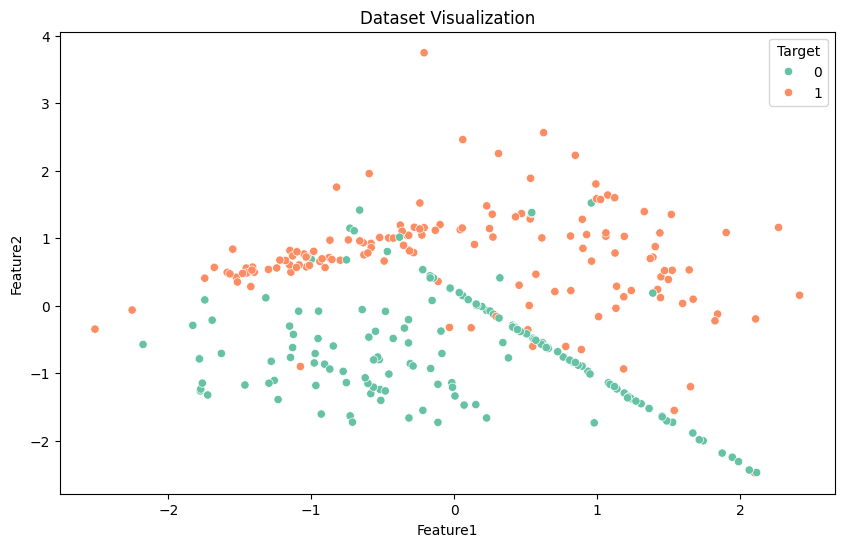

In [109]:
# Plotting the data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Feature1", y="Feature2", hue="Target", palette="Set2")
plt.title("Dataset Visualization")

In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [111]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    fit_intercept=False,
    penalty=None,
    solver="sag",
    max_iter=1000
)
lr.fit(X_train,y_train)
m = lr.coef_
b = lr.intercept_

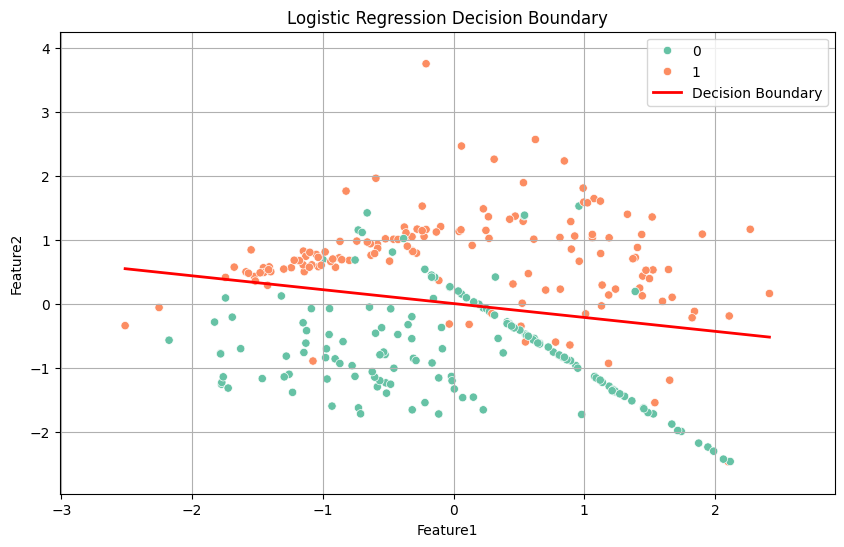

In [112]:
plt.figure(figsize=(10,6))

# Scatter plot
sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Target",
    palette="Set2"
)

# Decision boundary
x = np.linspace(df["Feature1"].min(), df["Feature1"].max(), 100)

if abs(m[0][1]) > 1e-6:
    y = -(m[0][0] * x + b[0]) / m[0][1]
    plt.plot(x, y, color="red", linewidth=2, label="Decision Boundary")
else:
    x0 = -b[0] / m[0][0]
    plt.axvline(x=x0, color="red", linewidth=2, label="Decision Boundary")

# Set limits
plt.xlim(df["Feature1"].min()-0.5, df["Feature1"].max()+0.5)
plt.ylim(df["Feature2"].min()-0.5, df["Feature2"].max()+0.5)

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

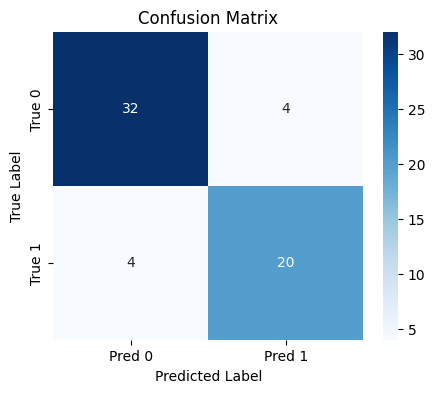

In [113]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

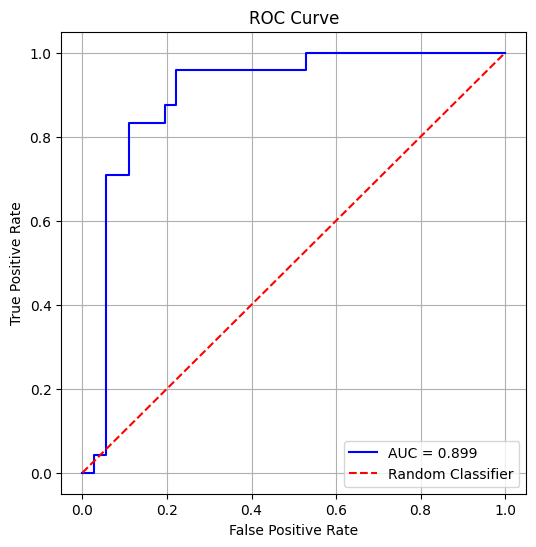

In [114]:
# AUC-ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of the positive class
y_prob = lr.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'r--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [115]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def fit(X, y, lr=0.01, epochs=1000):
    m, n = X.shape

    w = np.zeros((n, 1))
    y = y.reshape(-1, 1)

    losses = []

    for i in range(epochs):
        y_hat = sigmoid(X @ w)

        loss = -np.mean(y*np.log(y_hat + 1e-10) +
                        (1-y)*np.log(1-y_hat + 1e-10))
        losses.append(loss)

        dw = (X.T @ (y_hat - y)) / m

        w = w - lr * dw

    return w, losses


def predict_proba(X, w):
    return sigmoid(X @ w)


def predict(X, w):
    p = predict_proba(X, w)
    return (p >= 0.5).astype(int)

In [116]:
w, losses = fit(X_train, y_train, lr=0.1, epochs=1000)

In [117]:
y_pred = predict(X_test, w)

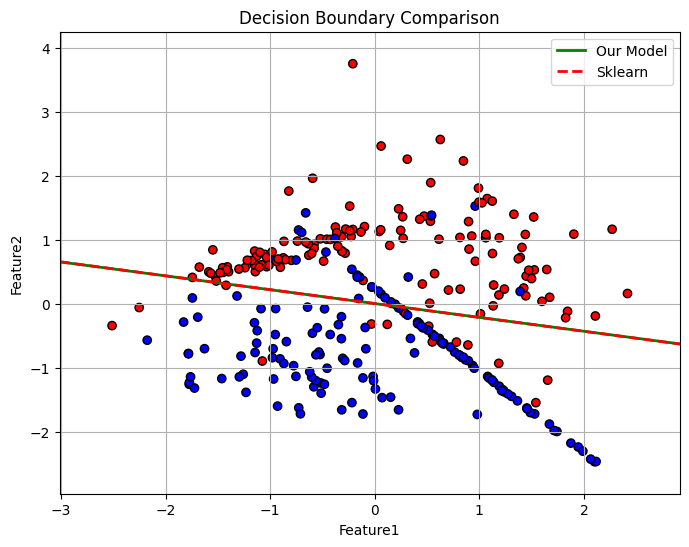

In [118]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["Target"],
    cmap="bwr",
    edgecolors="k"
)

xmin = df["Feature1"].min() - 0.5
xmax = df["Feature1"].max() + 0.5
ymin = df["Feature2"].min() - 0.5
ymax = df["Feature2"].max() + 0.5

x = np.linspace(xmin, xmax, 500)

if w.shape[0] == 3:
    y = -(w[0,0] + w[1,0]*x) / w[2,0]
else:
    y = -(w[0,0]*x) / w[1,0]

mask = (y >= ymin) & (y <= ymax)
plt.plot(x[mask], y[mask], color="green", lw=2, label="Our Model")

m = lr.coef_[0]
b = lr.intercept_[0]

y = -(b + m[0]*x) / m[1]
mask = (y >= ymin) & (y <= ymax)
plt.plot(x[mask], y[mask], color="red", lw=2, linestyle="--", label="Sklearn")

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Decision Boundary Comparison")
plt.legend()
plt.grid(True)
plt.show()

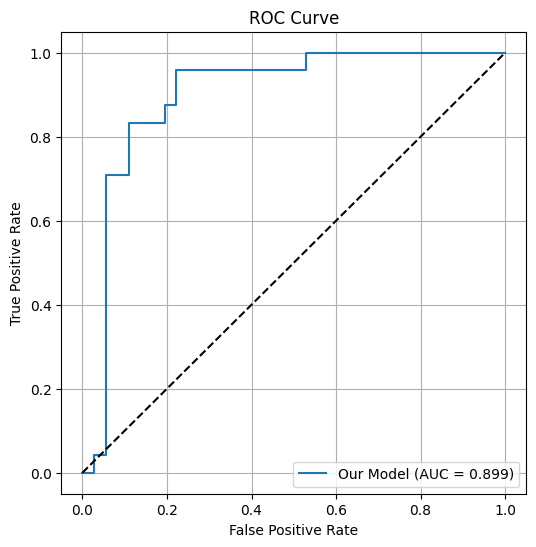

AUC: 0.8993055555555556


In [119]:
y_prob = sigmoid(X_test @ w).ravel()

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Our Model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("AUC:", auc)